# Task 8: Feature Engineering on Real-World Datasets

This notebook demonstrates core feature engineering techniques:

1. Handling missing values
2. Encoding categorical features
3. Feature scaling
4. Feature selection
5. Creating derived (new) features
.


## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_regression

pd.set_option('display.max_columns', None)


## 2. Load Dataset

In [3]:
df = pd.read_csv('Mall_Customers.csv')

print(df.shape)
df.head()


(200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## 3. Handling Missing Values

In [5]:
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

# General-purpose imputation (dataset is already clean, shown for completeness)
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Total missing values: 0


## 4. Creating Derived Features
Engineering new, more informative features from the raw columns.

In [6]:
# Rename for easier handling
df.rename(columns={'Annual Income (k$)': 'AnnualIncome_k',
                    'Spending Score (1-100)': 'SpendingScore'}, inplace=True)

# Income-to-spending ratio: how much of their income "potential" a customer actually spends
df['income_spending_ratio'] = df['SpendingScore'] / df['AnnualIncome_k']

# Age groups (life-stage bins)
df['age_group'] = pd.cut(
    df['Age'],
    bins=[0, 25, 35, 50, 65, 100],
    labels=['young_adult', 'adult', 'middle_aged', 'senior_adult', 'senior']
)

# High-value customer flag: above-median income AND above-median spending score
income_median = df['AnnualIncome_k'].median()
spending_median = df['SpendingScore'].median()
df['high_value_customer'] = (
    (df['AnnualIncome_k'] > income_median) & (df['SpendingScore'] > spending_median)
).astype(int)

df[['Age', 'age_group', 'AnnualIncome_k', 'SpendingScore',
    'income_spending_ratio', 'high_value_customer']].head()


,Age,age_group,AnnualIncome_k,SpendingScore,income_spending_ratio,high_value_customer
0,19,young_adult,15,39,2.600000,0
1,21,young_adult,15,81,5.400000,0
2,20,young_adult,16,6,0.375000,0
3,23,young_adult,16,77,4.812500,0
4,31,adult,17,40,2.352941,0


## 5. Encoding Categorical Features
- **Label Encoding** for the binary `Gender` column
- **One-Hot Encoding** for the nominal `age_group` column

In [7]:
le = LabelEncoder()
df['Gender_encoded'] = le.fit_transform(df['Gender'])   # Female/Male -> 0/1

df = pd.get_dummies(df, columns=['age_group'], prefix='agegrp')

df.head()


,CustomerID,Gender,Age,AnnualIncome_k,SpendingScore,income_spending_ratio,high_value_customer,Gender_encoded,agegrp_young_adult,agegrp_adult,agegrp_middle_aged,agegrp_senior_adult,agegrp_senior
0,1,Male,19,15,39,2.600000,0,1,True,False,False,False,False
1,2,Male,21,15,81,5.400000,0,1,True,False,False,False,False
2,3,Female,20,16,6,0.375000,0,0,True,False,False,False,False
3,4,Female,23,16,77,4.812500,0,0,True,False,False,False,False
4,5,Female,31,17,40,2.352941,0,0,False,True,False,False,False


## 6. Feature Scaling
Scale numeric features so they're comparable in range — important for distance-based
algorithms like K-Means (Task 10) and KNN (Task 9).

In [8]:
numeric_cols = ['Age', 'AnnualIncome_k', 'SpendingScore', 'income_spending_ratio']

# Standardization (mean=0, std=1)
scaler_std = StandardScaler()
df_scaled_std = df.copy()
df_scaled_std[numeric_cols] = scaler_std.fit_transform(df[numeric_cols])

# Min-Max normalization (0 to 1)
scaler_mm = MinMaxScaler()
df_scaled_mm = df.copy()
df_scaled_mm[numeric_cols] = scaler_mm.fit_transform(df[numeric_cols])

print("Standardized sample:")
display(df_scaled_std[numeric_cols].head())

print("\nMin-Max scaled sample:")
display(df_scaled_mm[numeric_cols].head())


Standardized sample:


,Age,AnnualIncome_k,SpendingScore,income_spending_ratio
0,-1.424569,-1.738999,-0.434801,1.577244
1,-1.281035,-1.738999,1.195704,4.460960
2,-1.352802,-1.700830,-1.715913,-0.714279
3,-1.137502,-1.700830,1.040418,3.855894
4,-0.563369,-1.662660,-0.395980,1.322799



Min-Max scaled sample:


,Age,AnnualIncome_k,SpendingScore,income_spending_ratio
0,0.019231,0.000000,0.387755,0.480248
1,0.057692,0.000000,0.816327,1.000000
2,0.038462,0.008197,0.051020,0.067230
3,0.096154,0.008197,0.775510,0.890945
4,0.250000,0.016393,0.397959,0.434387


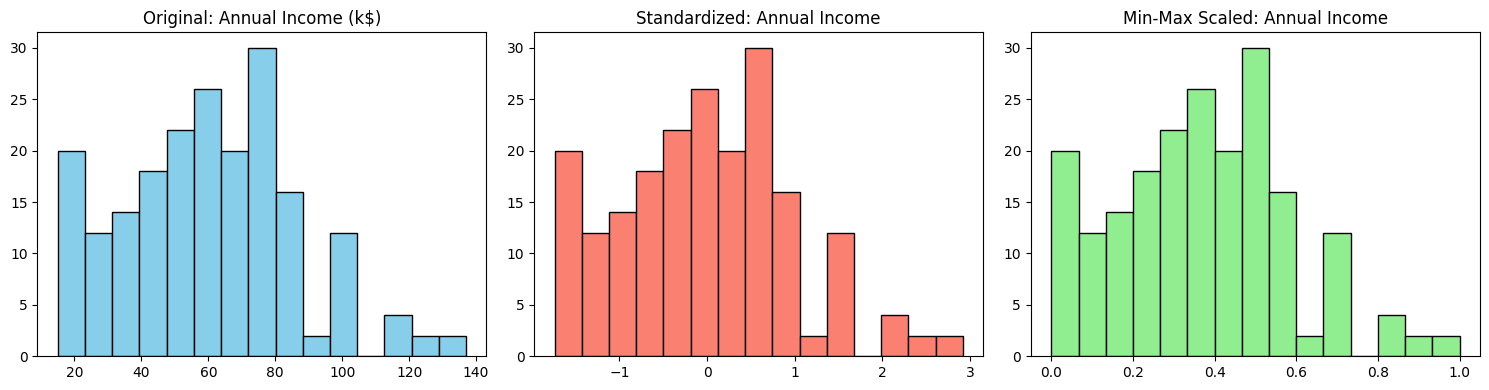

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(df['AnnualIncome_k'], bins=15, color='skyblue', edgecolor='black')
axes[0].set_title('Original: Annual Income (k$)')

axes[1].hist(df_scaled_std['AnnualIncome_k'], bins=15, color='salmon', edgecolor='black')
axes[1].set_title('Standardized: Annual Income')

axes[2].hist(df_scaled_mm['AnnualIncome_k'], bins=15, color='lightgreen', edgecolor='black')
axes[2].set_title('Min-Max Scaled: Annual Income')

plt.tight_layout()
plt.show()


## 7. Feature Selection
Use `SelectKBest` (F-test) to rank features by how strongly they relate to `SpendingScore`.

In [10]:
feature_cols = [c for c in df.columns if c not in
                 ['CustomerID', 'Gender', 'SpendingScore']
                 and df[c].dtype != 'object']

X = df[feature_cols].select_dtypes(include=[np.number]).fillna(0)
y = df['SpendingScore']

selector = SelectKBest(score_func=f_regression, k=min(6, X.shape[1]))
selector.fit(X, y)

scores = pd.DataFrame({
    'feature': X.columns,
    'f_score': selector.scores_
}).sort_values(by='f_score', ascending=False)

print("Feature ranking by F-score (relationship with Spending Score):")
scores


Feature ranking by F-score (relationship with Spending Score):


,feature,f_score
2,income_spending_ratio,107.517628
3,high_value_customer,106.042957
0,Age,23.743746
4,Gender_encoded,0.670837
1,AnnualIncome_k,0.019419


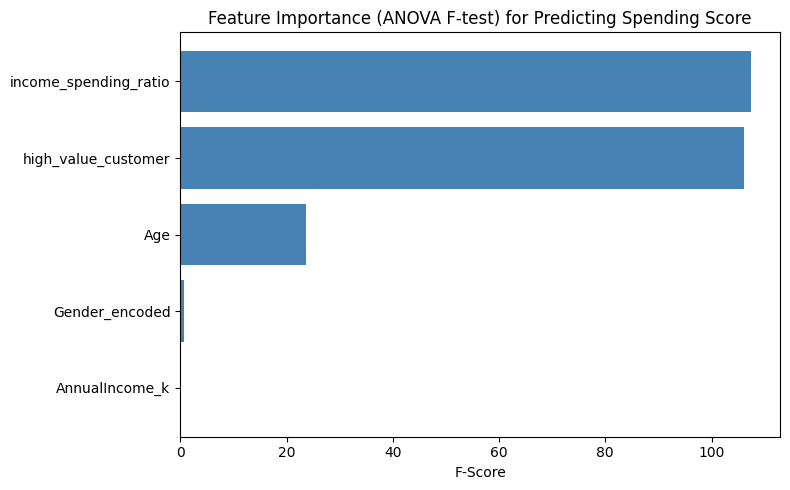

In [11]:
plt.figure(figsize=(8, 5))
plt.barh(scores['feature'], scores['f_score'], color='steelblue')
plt.xlabel('F-Score')
plt.title('Feature Importance (ANOVA F-test) for Predicting Spending Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 8. Summary

| Step | Technique Used |
|------|-----------------|
| Missing values | Median/mode imputation (dataset was already clean) |
| Derived features | `income_spending_ratio`, `age_group`, `high_value_customer` |
| Encoding | Label Encoding (`Gender`), One-Hot Encoding (`age_group`) |
| Scaling | StandardScaler, MinMaxScaler |
| Feature selection | SelectKBest (F-test) against `SpendingScore` |

These engineered features are well suited as inputs to the clustering (K-Means / Hierarchical)
work from Task 10, since Mall Customers is a classic customer-segmentation dataset.
